# Top 5 Stations Trend Visualization (2023-2025)

이 노트북은 원천 데이터에서 `rental_count + return_count` 기준 이용량 상위 5개 대여소를 자동으로 추출한 뒤, 각 대여소의 `시간별`, `요일별`, `월별`, `년도별` 추이를 시각화합니다.

- 상위 5개 대여소 선정
- 각 대여소별 `rental_count`와 `return_count` 비교
- `시간별`, `요일별`, `월별` 그래프는 `2023`, `2024`, `2025`를 같은 축에 겹쳐서 표시
- 연도별 패턴이 서로 유사한지 확인

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')


In [6]:
search_roots = [Path('..').resolve(), Path('..').resolve().parent]
source_candidates = []
for root in search_roots:
    source_candidates.extend(root.rglob('station_hour_bike_flow_2023_2025.csv'))

source_candidates = sorted({path.resolve() for path in source_candidates})
if not source_candidates:
    raise FileNotFoundError('station_hour_bike_flow_2023_2025.csv not found in workspace')

SOURCE_PATH = source_candidates[0]
print(SOURCE_PATH)


C:\Users\TJ\ddri_work\3조 공유폴더\station_hour_bike_flow_2023_2025\station_hour_bike_flow_2023_2025.csv


In [7]:
use_cols = ['station_id', 'time', 'rental_count', 'return_count', 'year', 'month', 'weekday', 'hour']
df = pd.read_csv(SOURCE_PATH, usecols=use_cols, parse_dates=['time'])

station_usage = (
    df.groupby('station_id', as_index=False)
    .agg(
        rental_sum=('rental_count', 'sum'),
        return_sum=('return_count', 'sum')
    )
)
station_usage['usage_sum'] = station_usage['rental_sum'] + station_usage['return_sum']
top5_station_df = station_usage.sort_values('usage_sum', ascending=False).head(5).reset_index(drop=True)
top5_station_ids = top5_station_df['station_id'].tolist()

display(top5_station_df)
print('top5_station_ids =', top5_station_ids)

top_df = df[df['station_id'].isin(top5_station_ids)].copy()


,station_id,rental_sum,return_sum,usage_sum
0,2377,50004,61229,111233
1,2335,51418,56980,108398
2,2348,45092,57133,102225
3,2340,44362,50649,95011
4,2404,46276,47538,93814


top5_station_ids = [2377, 2335, 2348, 2340, 2404]


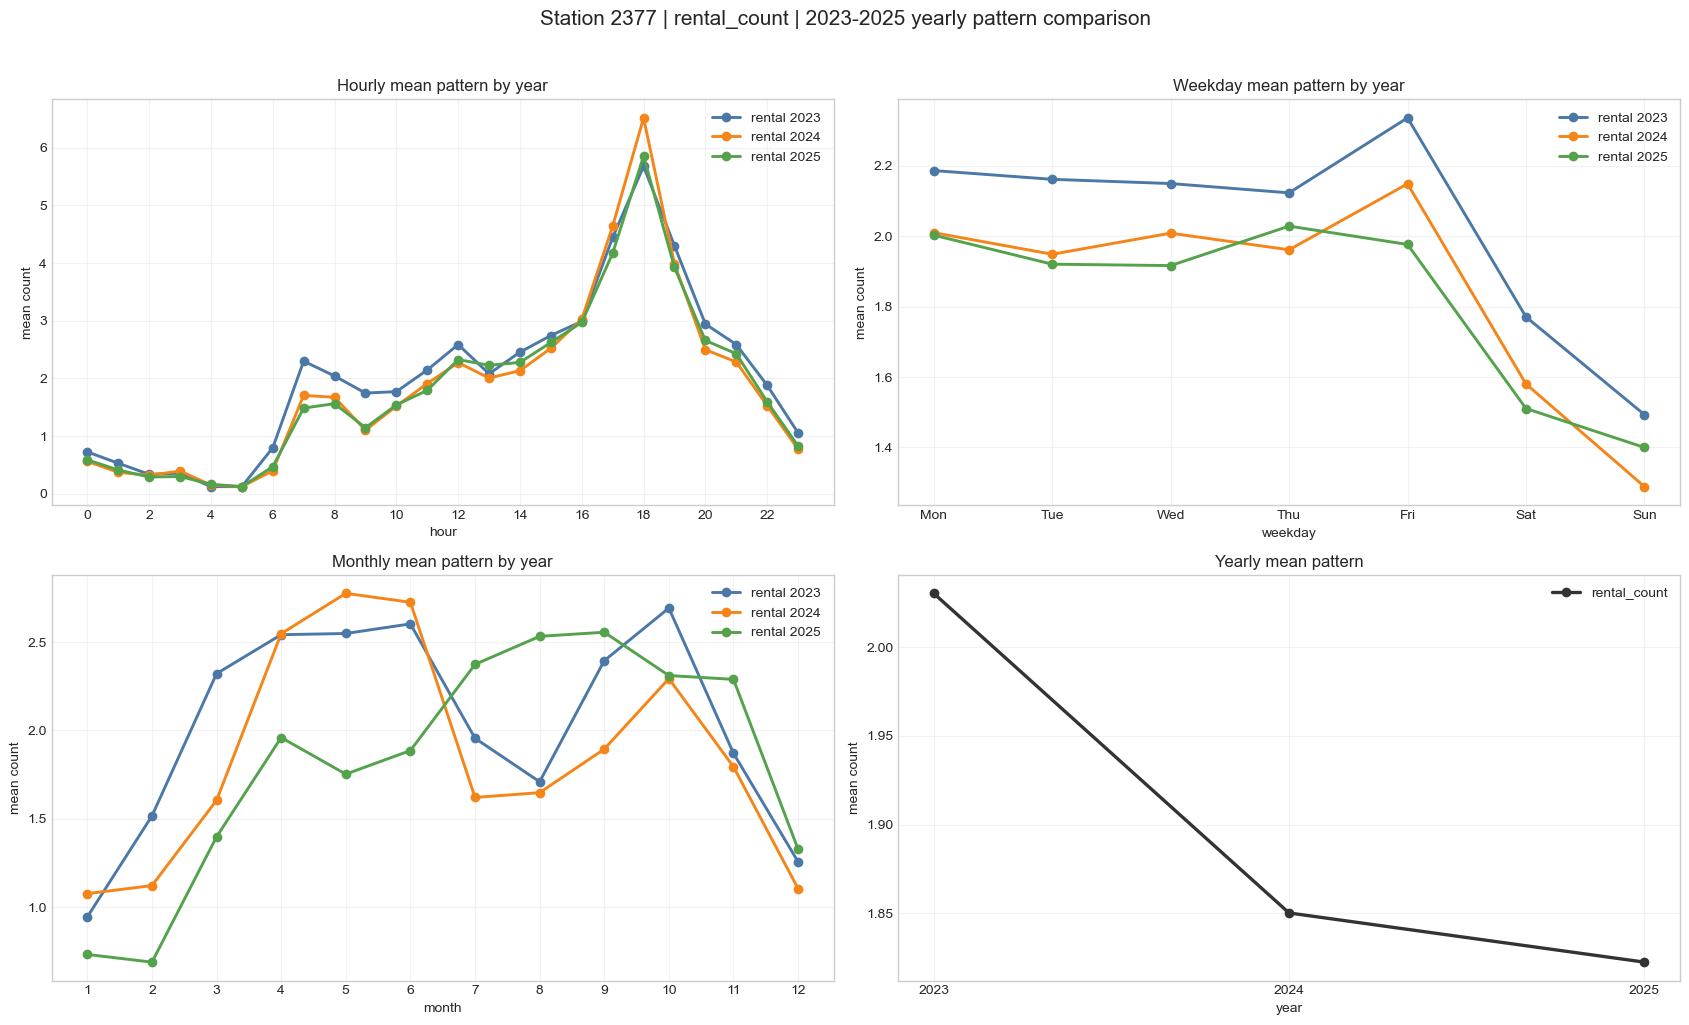

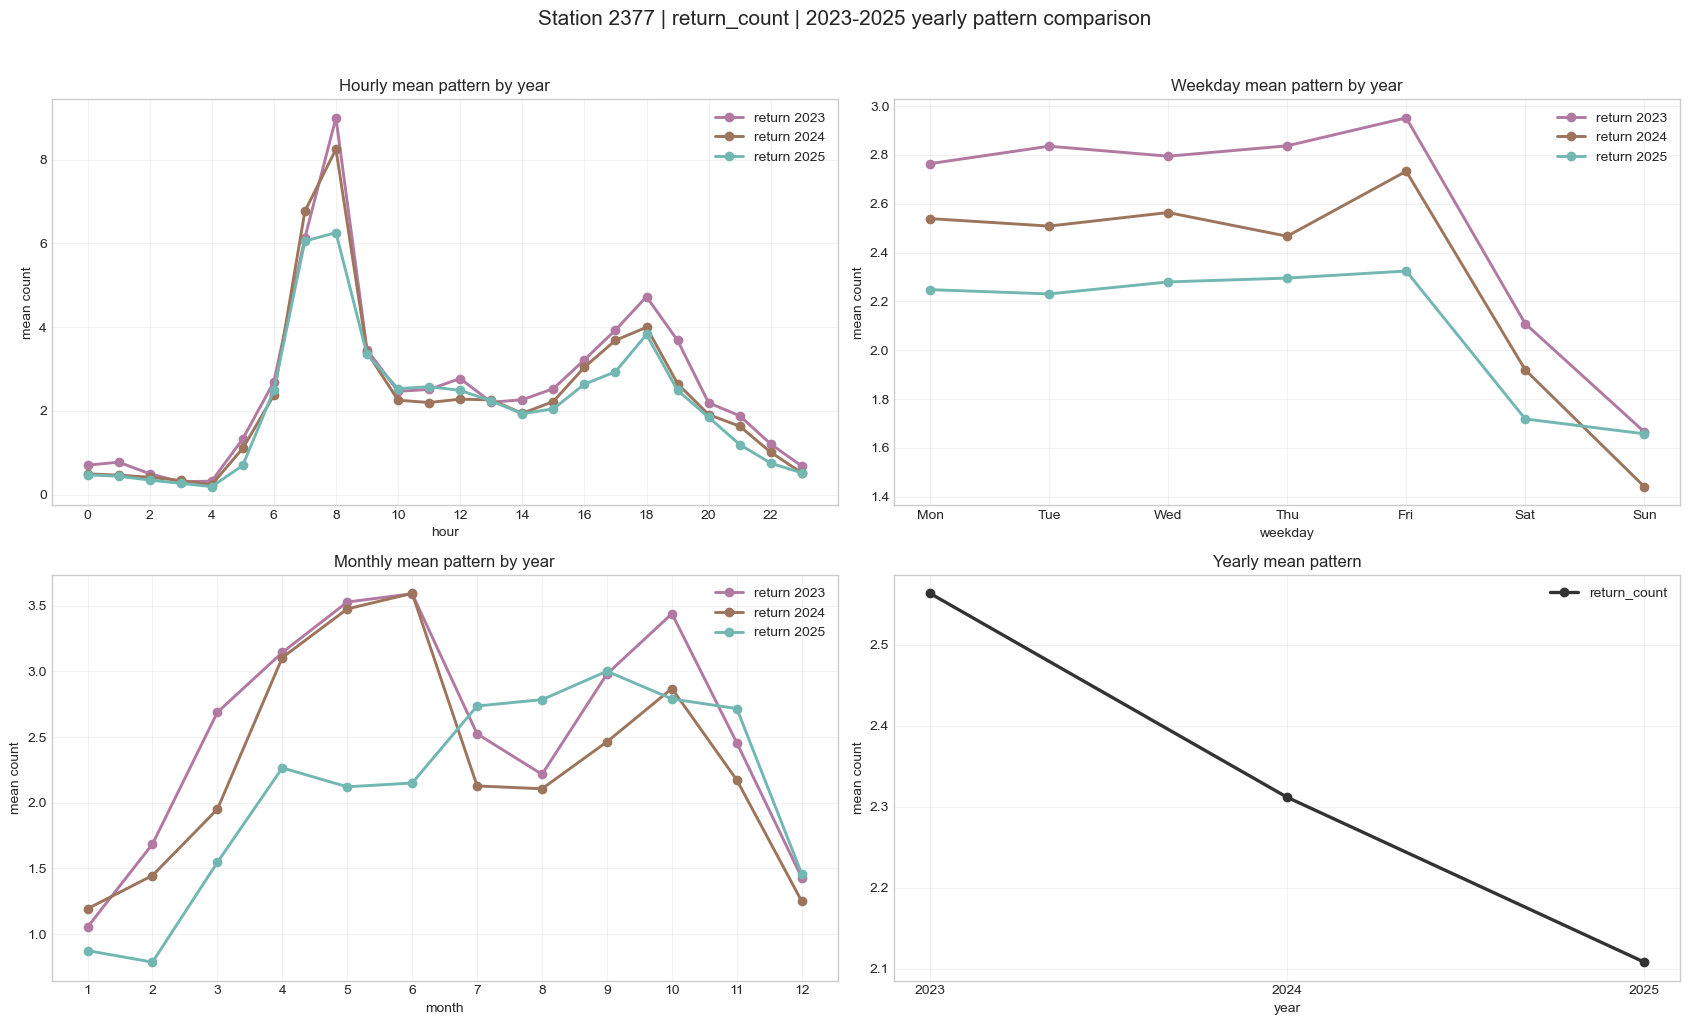

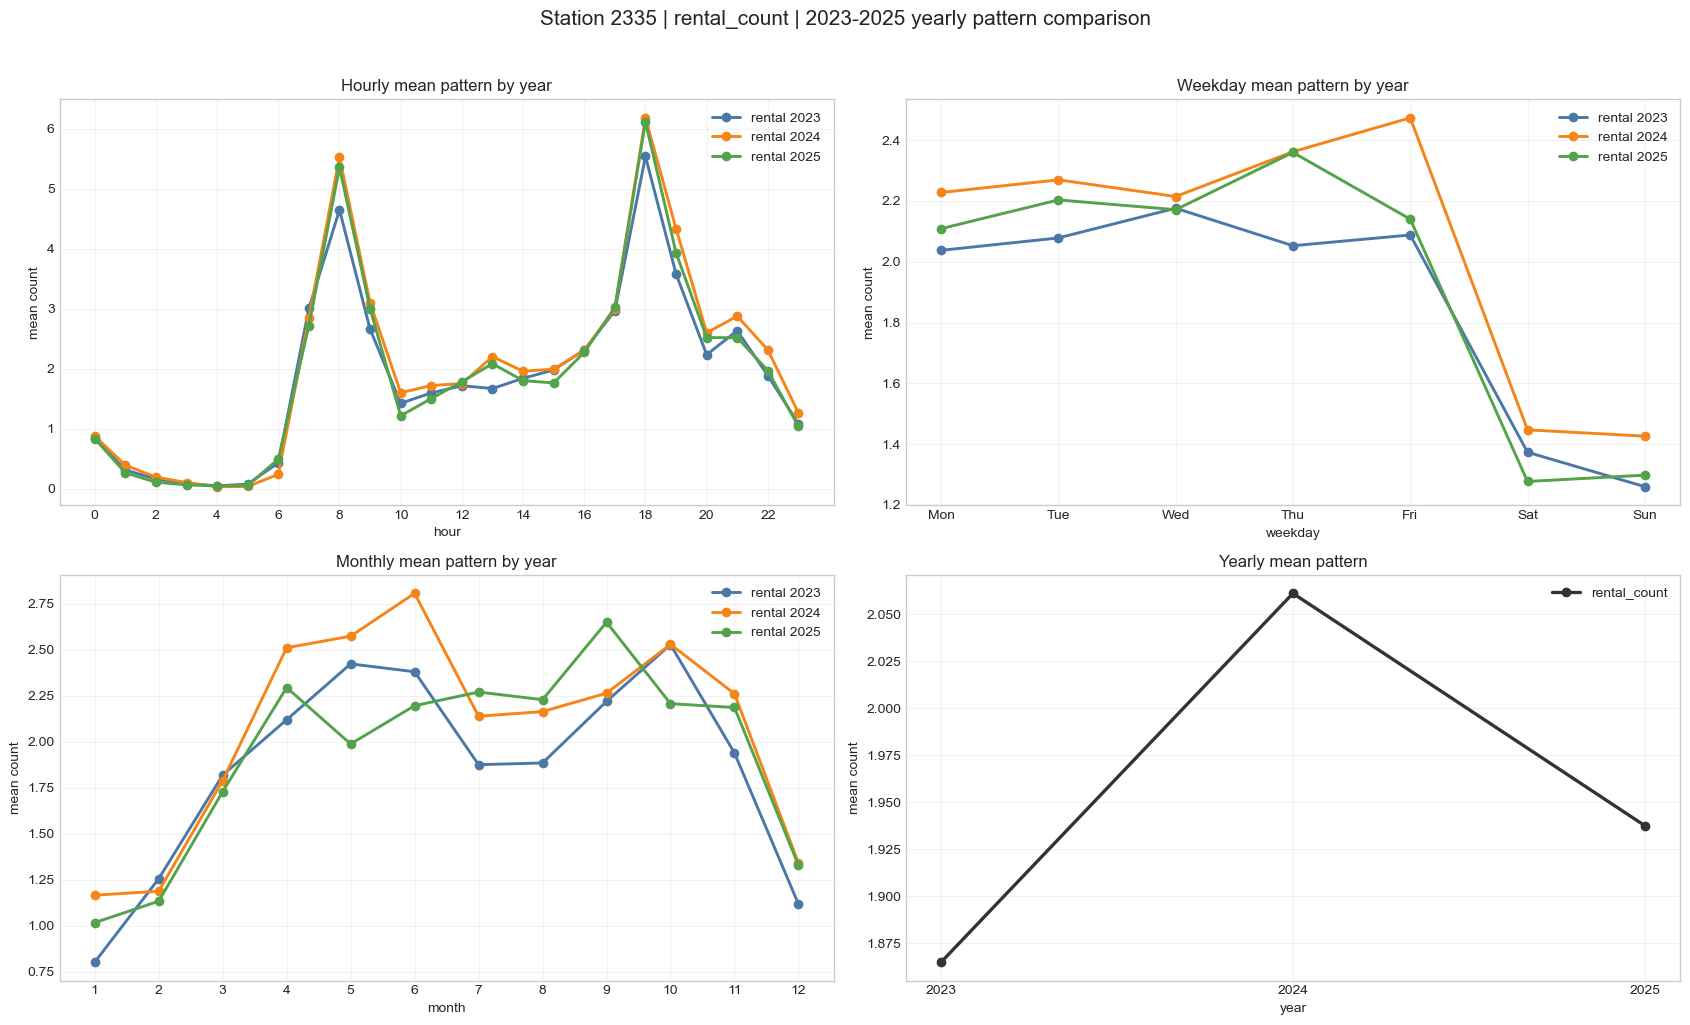

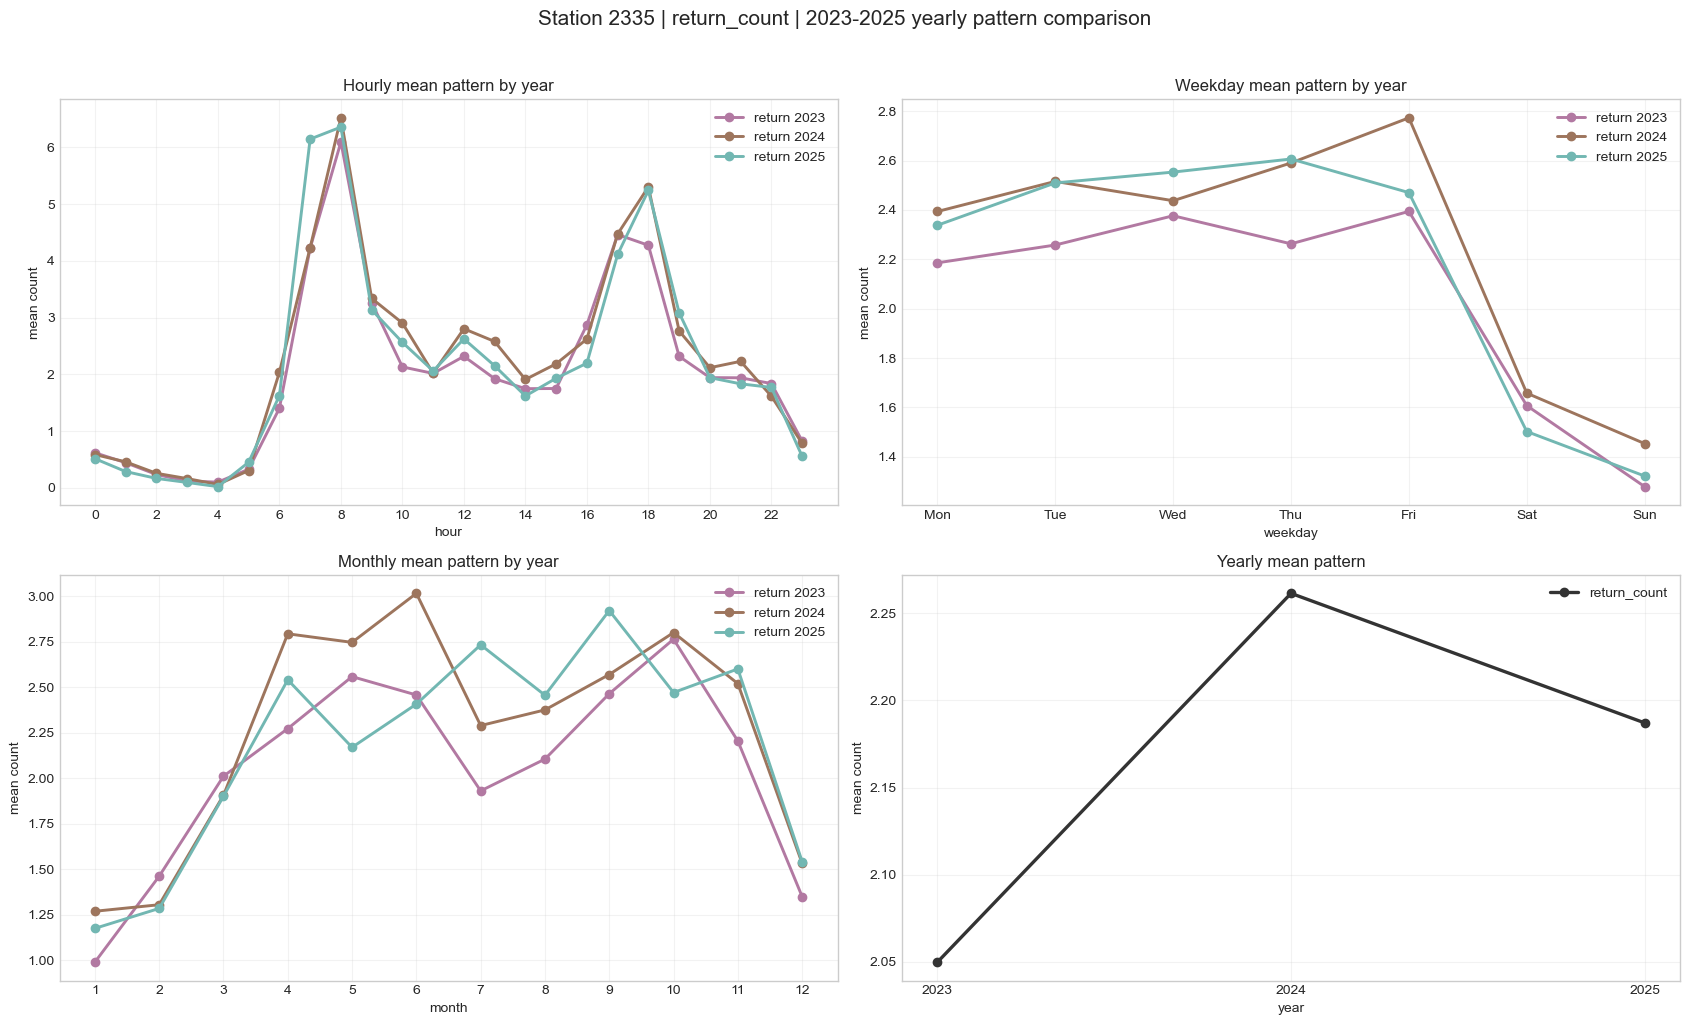

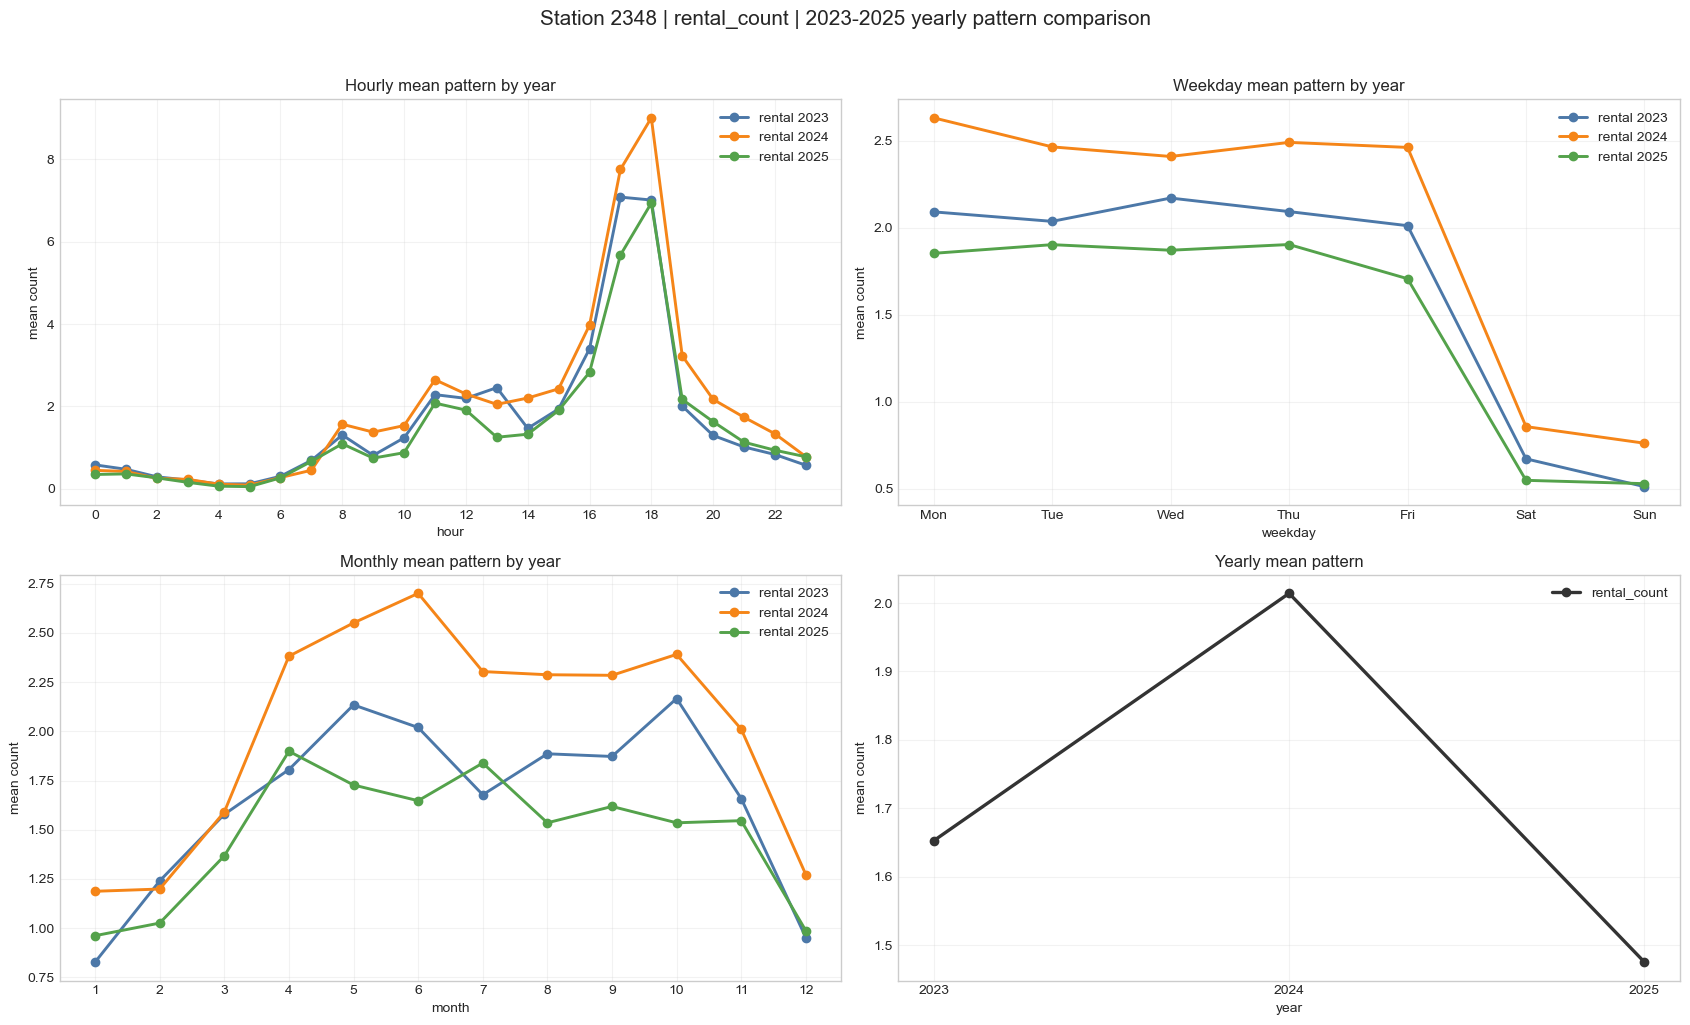

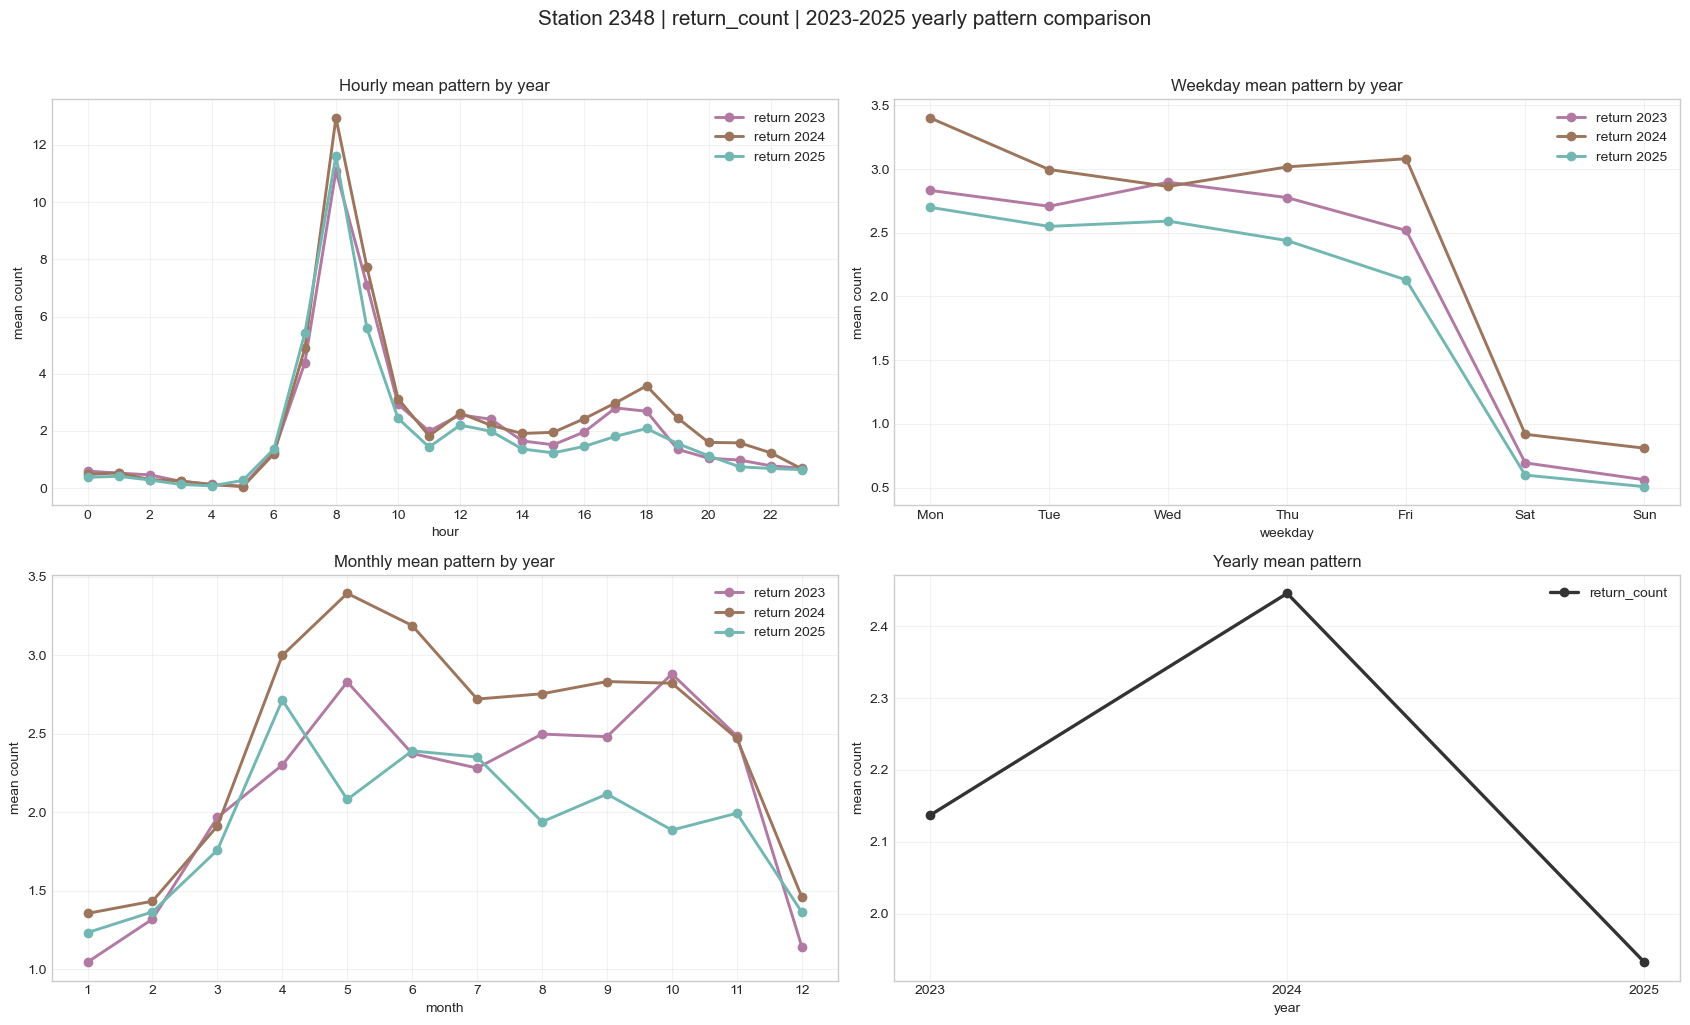

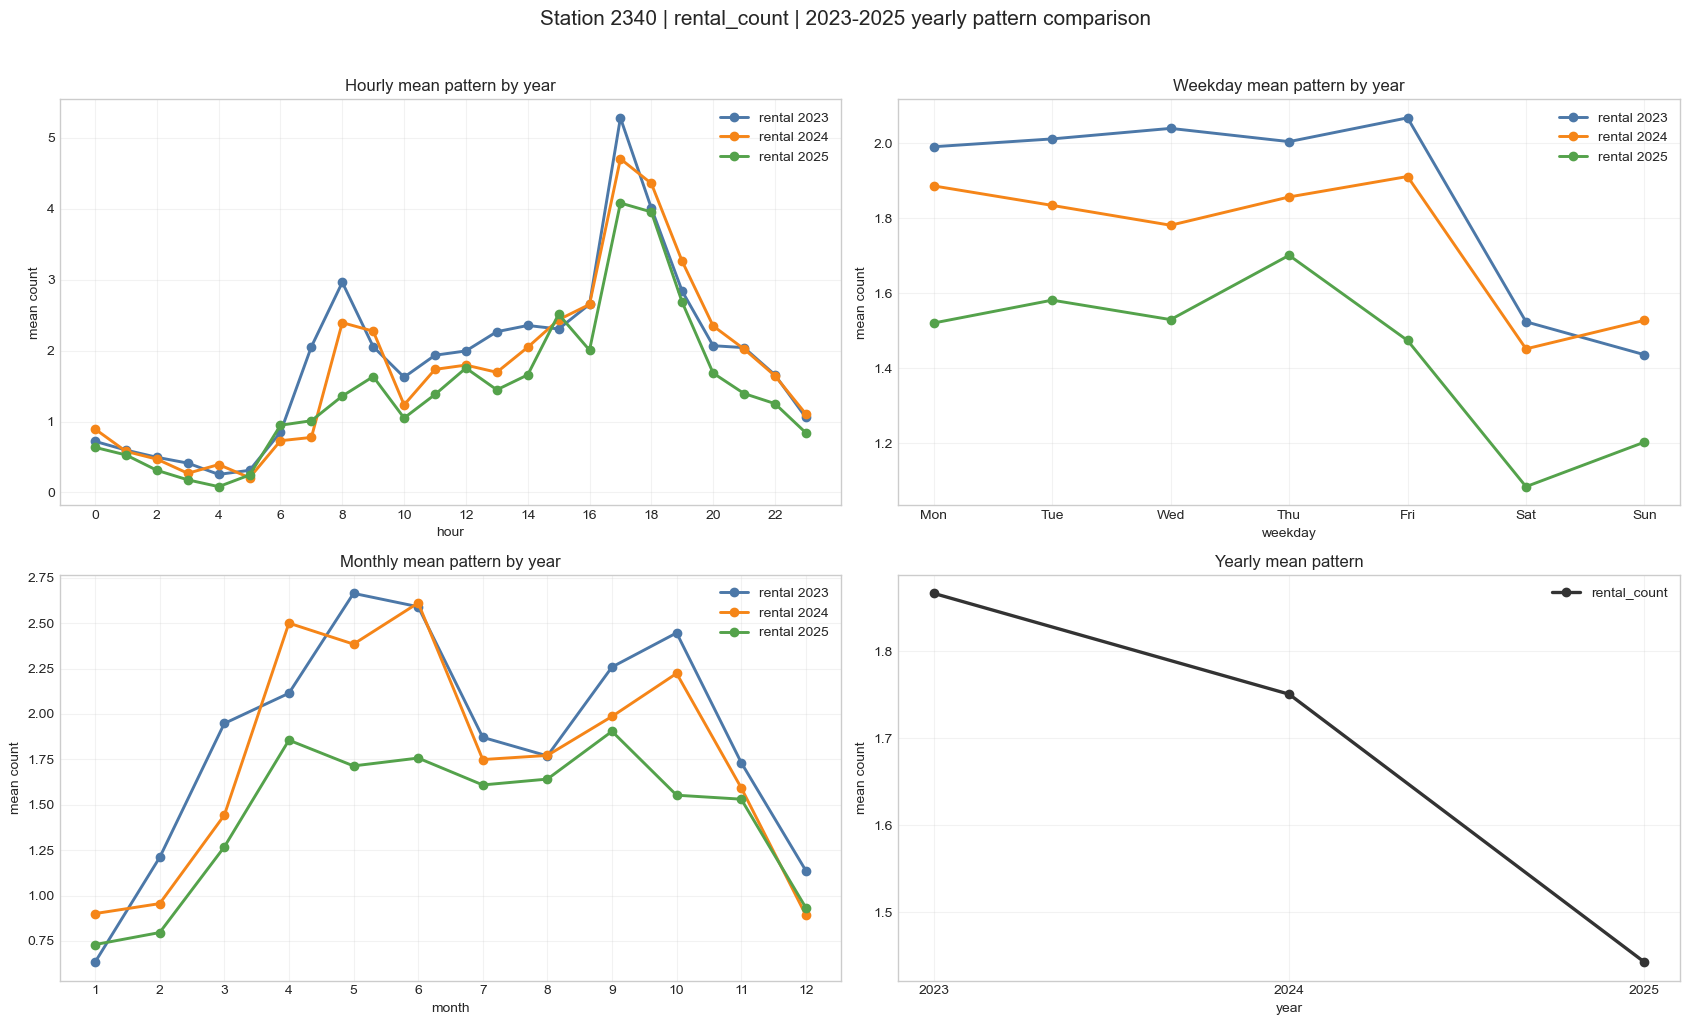

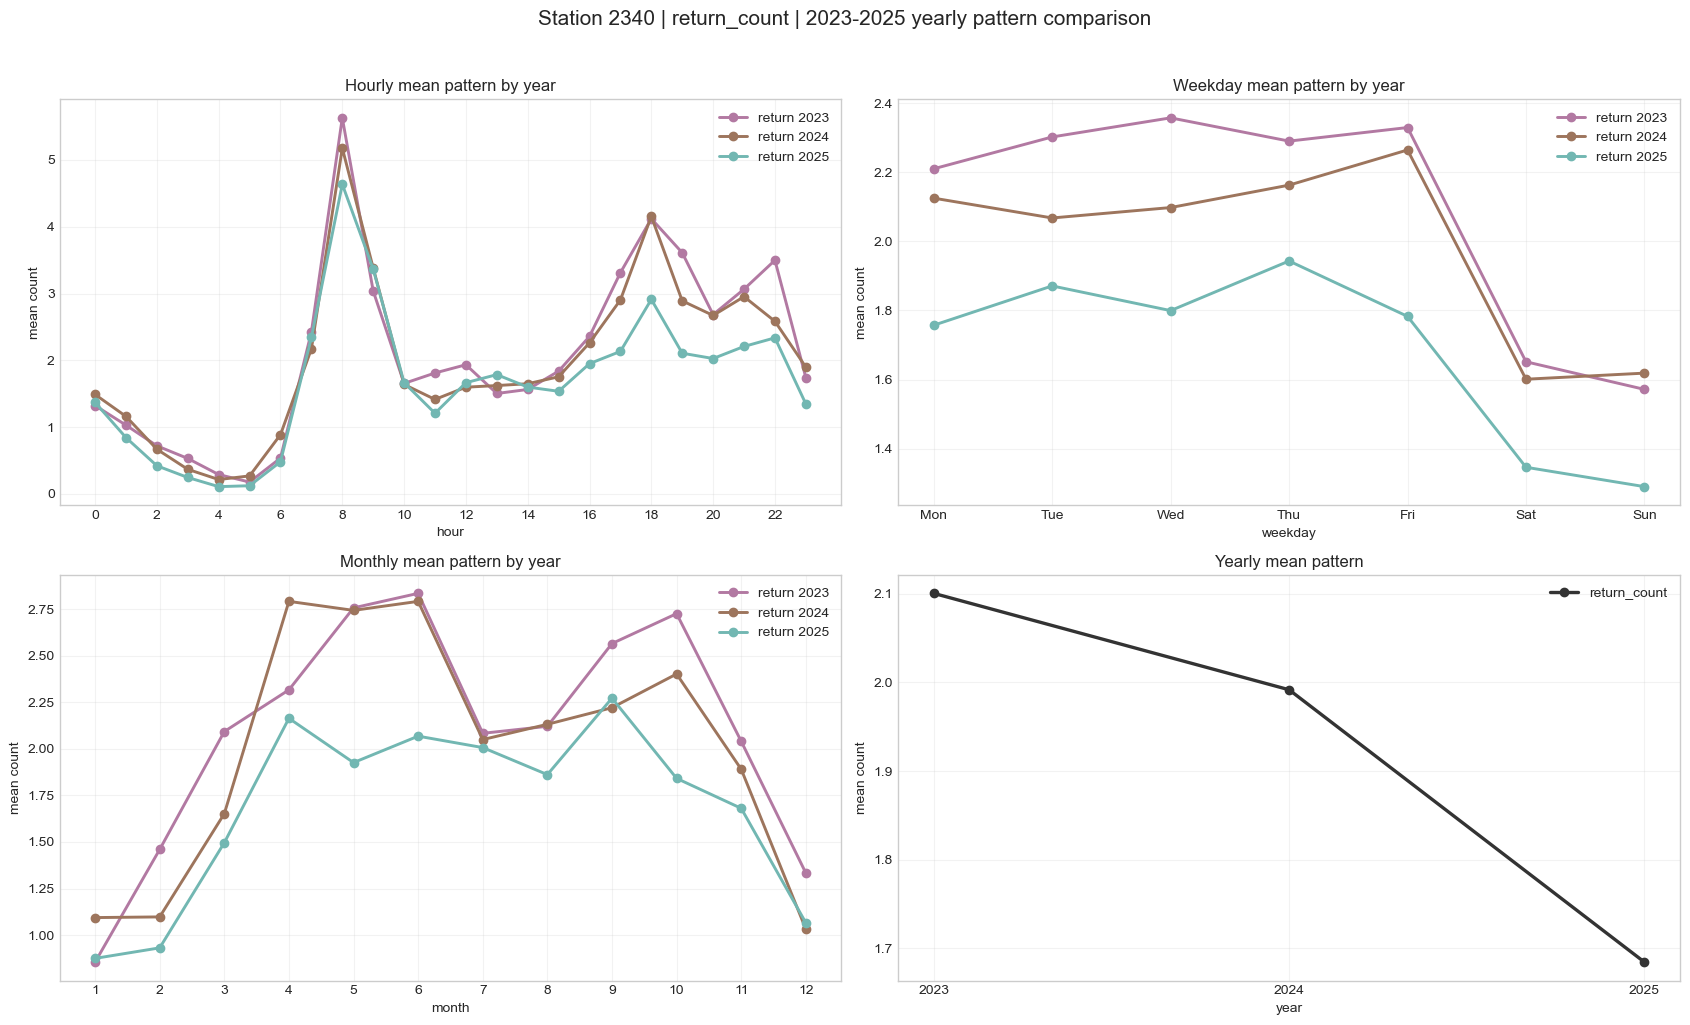

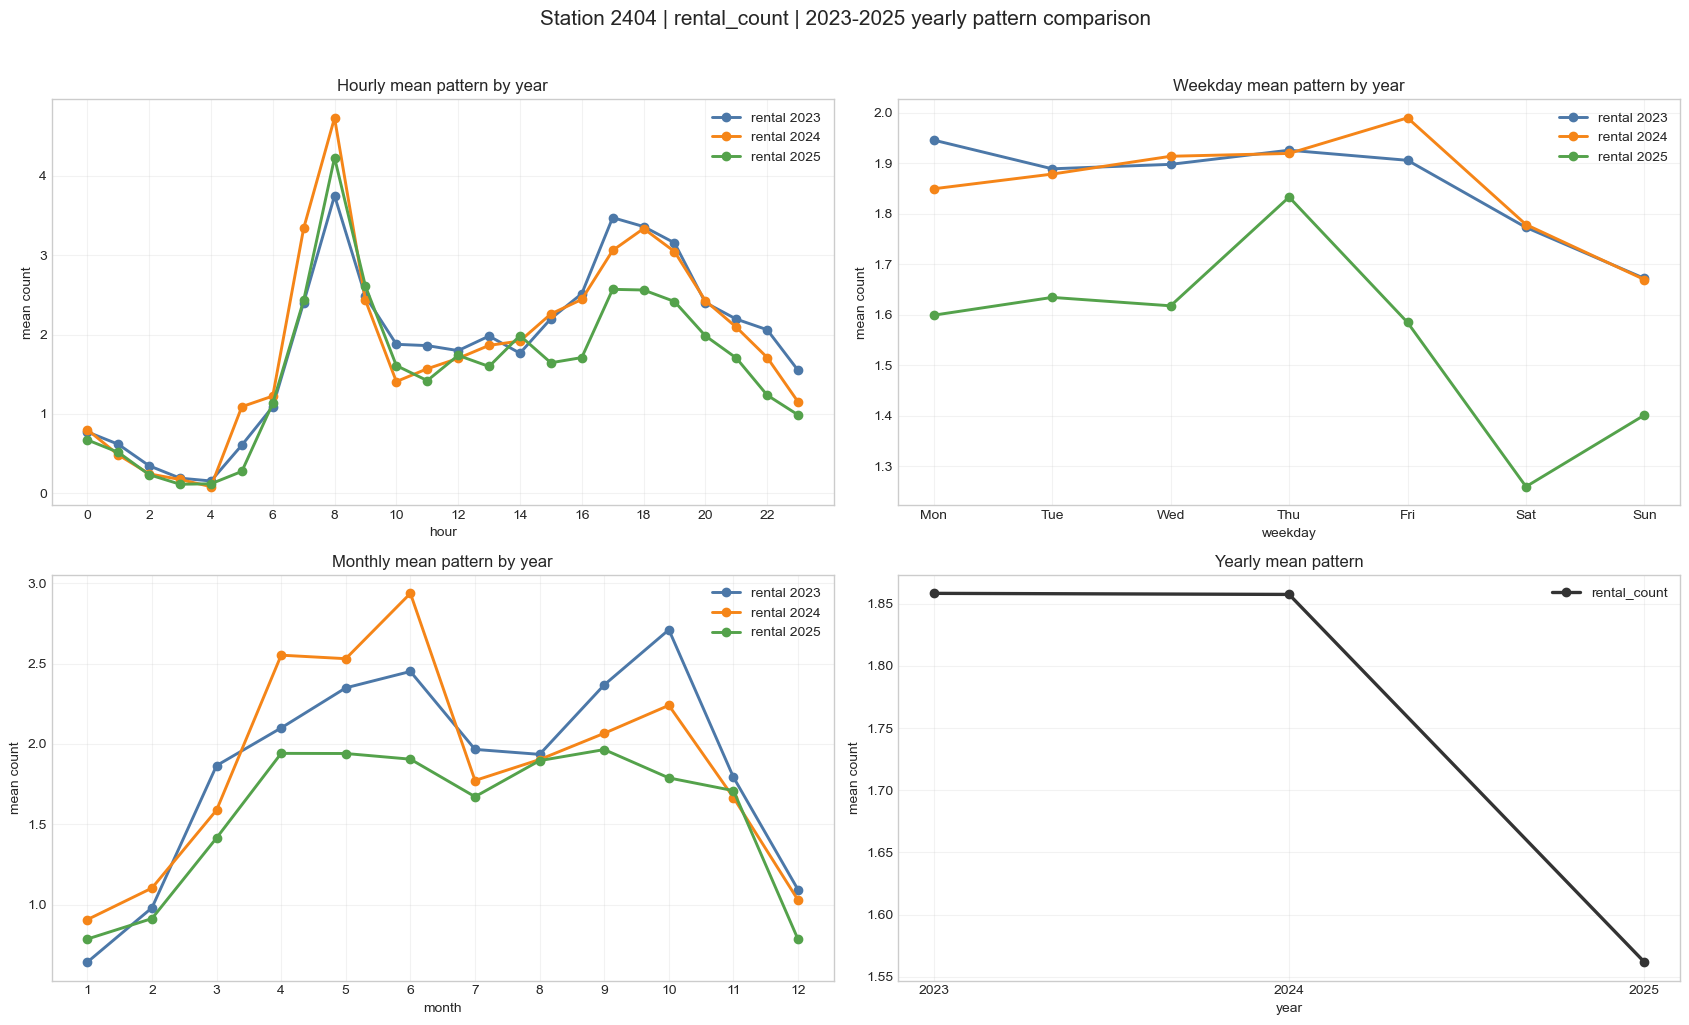

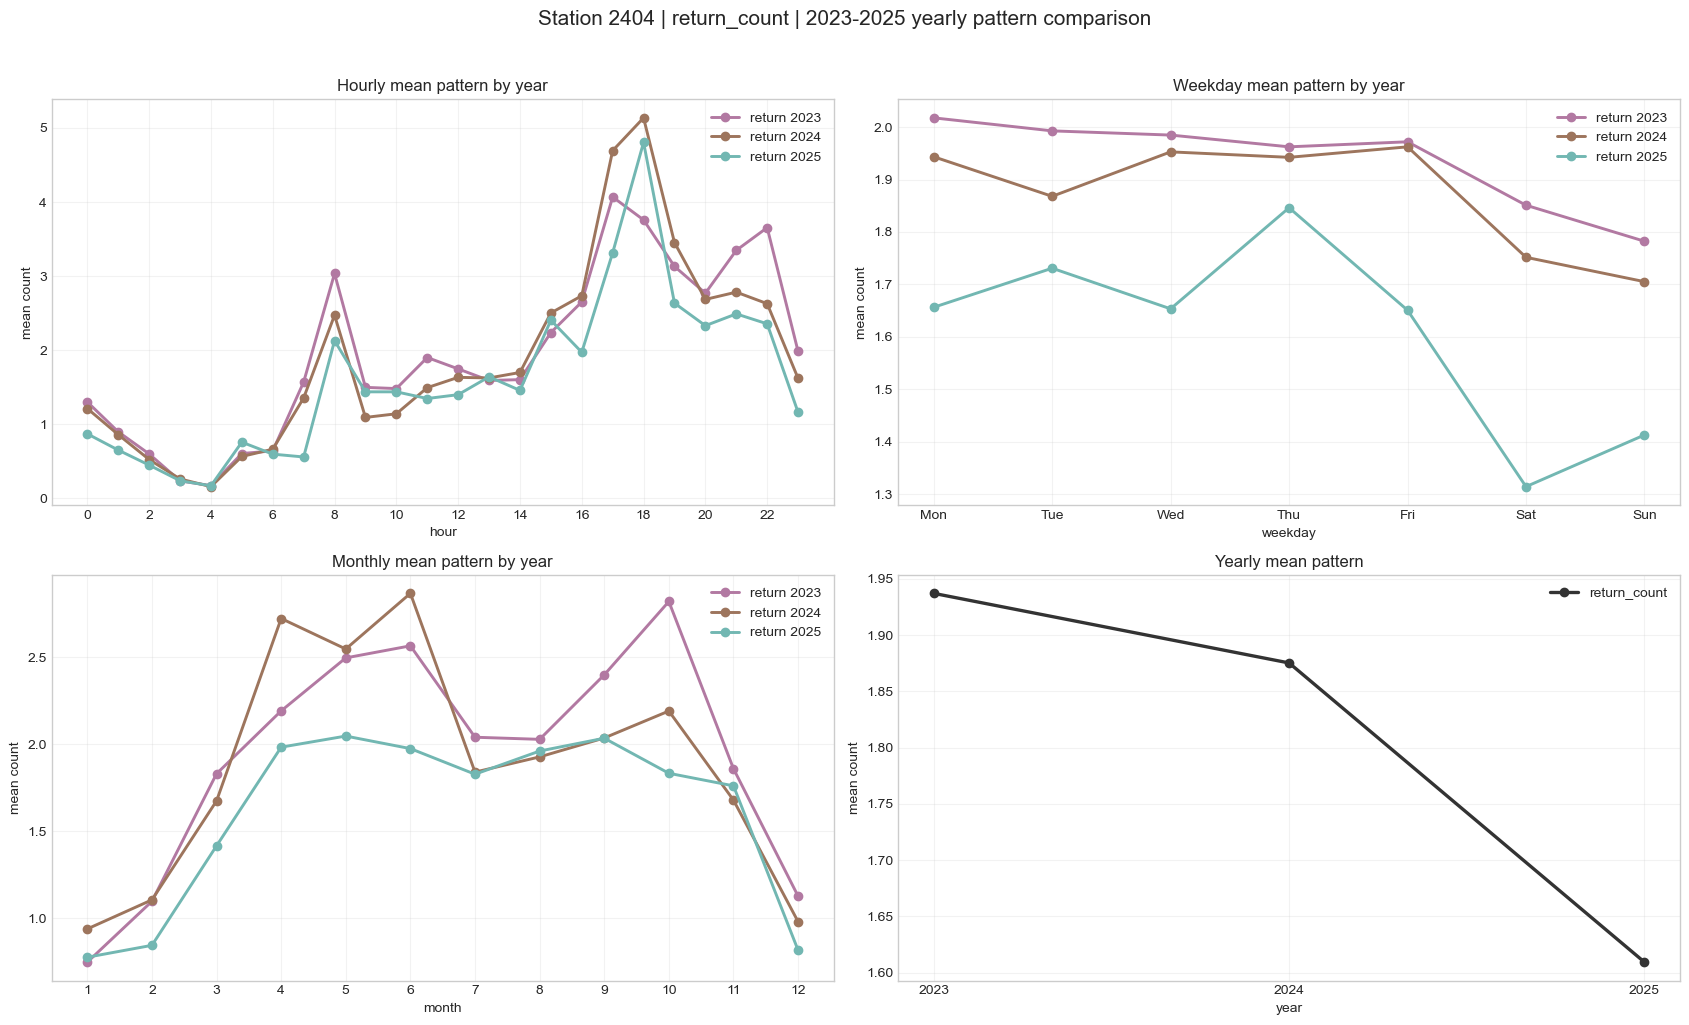

In [8]:
weekday_label_map = {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun',
}

for station_id in top5_station_ids:
    station_df = top_df[top_df['station_id'] == station_id].copy()

    for target, color_map, label_prefix in [
        ('rental_count', ['#4C78A8', '#F58518', '#54A24B'], 'rental'),
        ('return_count', ['#B279A2', '#9D755D', '#72B7B2'], 'return'),
    ]:
        fig, axes = plt.subplots(2, 2, figsize=(17, 10))
        fig.suptitle(f'Station {station_id} | {target} | 2023-2025 yearly pattern comparison', fontsize=15, y=1.02)

        for year, color in zip([2023, 2024, 2025], color_map):
            year_df = station_df[station_df['year'] == year]
            hourly = year_df.groupby('hour', as_index=False)[target].mean()
            weekday = year_df.groupby('weekday', as_index=False)[target].mean()
            weekday['weekday_label'] = weekday['weekday'].map(weekday_label_map)
            monthly = year_df.groupby('month', as_index=False)[target].mean()

            axes[0, 0].plot(hourly['hour'], hourly[target], marker='o', linewidth=2.1, color=color, label=f'{label_prefix} {year}')
            axes[0, 1].plot(weekday['weekday_label'], weekday[target], marker='o', linewidth=2.1, color=color, label=f'{label_prefix} {year}')
            axes[1, 0].plot(monthly['month'], monthly[target], marker='o', linewidth=2.1, color=color, label=f'{label_prefix} {year}')

        yearly = station_df.groupby('year', as_index=False)[target].mean()
        axes[1, 1].plot(yearly['year'], yearly[target], marker='o', linewidth=2.4, color='#333333', label=target)

        axes[0, 0].set_title('Hourly mean pattern by year')
        axes[0, 0].set_xlabel('hour')
        axes[0, 0].set_ylabel('mean count')
        axes[0, 0].set_xticks(range(0, 24, 2))
        axes[0, 0].legend()

        axes[0, 1].set_title('Weekday mean pattern by year')
        axes[0, 1].set_xlabel('weekday')
        axes[0, 1].set_ylabel('mean count')
        axes[0, 1].legend()

        axes[1, 0].set_title('Monthly mean pattern by year')
        axes[1, 0].set_xlabel('month')
        axes[1, 0].set_ylabel('mean count')
        axes[1, 0].set_xticks(range(1, 13))
        axes[1, 0].legend()

        axes[1, 1].set_title('Yearly mean pattern')
        axes[1, 1].set_xlabel('year')
        axes[1, 1].set_ylabel('mean count')
        axes[1, 1].set_xticks([2023, 2024, 2025])
        axes[1, 1].legend()

        for ax in axes.ravel():
            ax.grid(alpha=0.25)

        plt.tight_layout()
        plt.show()
